In [6]:
from binding import line_sim as line
import matplotlib.pyplot as plt
import numpy as np

In [16]:
q=1

L = 300
T = 1000
kon = 1
koff = 1
kstep = 100
kq = 10

In [17]:
def exponential_func(x, a, b):
    return a * np.exp(-b * x)

def get_binding_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==0)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def get_stepping_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==2)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def fit (res, dt, func):   
    hist, bins = np.histogram(func(res, dt), bins=1000, density=True) 
    bin_centers = (bins[:-1] + bins[1:]) / 2
    params, covariance = curve_fit(exponential_func, bin_centers, hist)
    return params[1]


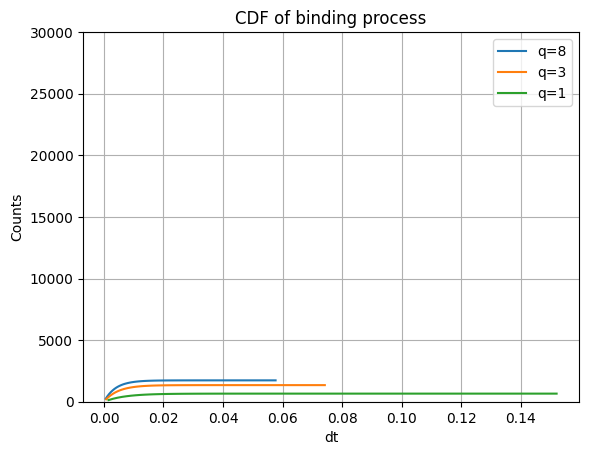

In [18]:
Q = [8,3,1]
# lamda = [0,0,0,0]

fig, ax = plt.subplots(1,1)

for i, q in enumerate(Q):
    data, times, res, dt = line(L,T, kon, koff, kstep, kq, q)
    data = np.array(data)
    time = np.array(times)
    res = np.array(res)
    dt = np.array(dt)
    Diff = get_binding_data(res, dt)
    counts, bin_edges = np.histogram(Diff, bins=100, density=True)
    cdf = np.cumsum(counts)
    ax.plot(bin_edges[1:], cdf, label=f"q={q}")

    ax.set( ylim = [0,30000],xlabel="dt", ylabel="Counts", title="CDF of binding process")
    ax.legend()
    ax.grid()